In [63]:

# Imports

from ucimlrepo import fetch_ucirepo      # Libreria para interactuar con el repositorio UCI Machine Learning
import pandas as pd                      # Librería para manipulación y análisis de datos
import plotly.express as px              # Librería para crear gráficos interactivos y visualizaciones

In [64]:
# fetch dataset
beijing_pm2_5 = fetch_ucirepo(id=381)

# data (como pandas dataframes)
X = beijing_pm2_5.data.features
y = beijing_pm2_5.data.targets
df = pd.concat([X, y], axis=1)

# metadata
print(beijing_pm2_5.metadata)

# información de las variables
print(beijing_pm2_5.variables)

{'uci_id': 381, 'name': 'Beijing PM2.5', 'repository_url': 'https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data', 'data_url': 'https://archive.ics.uci.edu/static/public/381/data.csv', 'abstract': 'This hourly data set contains the PM2.5 data of US Embassy in Beijing. Meanwhile, meteorological data from Beijing Capital International Airport are also included. ', 'area': 'Climate and Environment', 'tasks': ['Regression'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 43824, 'num_features': 11, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['pm2.5'], 'index_col': ['No'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C5JS49', 'creators': ['Song Chen'], 'intro_paper': {'ID': 432, 'type': 'NATIVE', 'title': "Assessing Beijing's PM2.5 pollution: severity, weather impact, APEC and winter heating", 'authors': 'Xuan Liang, T. Zou, Bi

In [65]:
# generar indice
df.index = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.index.name = 'date'

#One-hot encoding para la columna 'cbwd'
df = pd.get_dummies(df, columns=['cbwd'], prefix='', prefix_sep='cbwd_', dtype=int)

#One-hot encoding para la columna month
df = pd.get_dummies(df, columns=['month'], prefix='', prefix_sep='month_', dtype=int)

#eliminar columnas year, day hour
df.drop(columns=['year', 'day', 'hour'], inplace=True)

display(df.columns)

Index(['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'pm2.5', 'cbwd_NE',
       'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'month_1', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12'],
      dtype='object')

In [66]:
# Generar variables importantes con lags

N_lags = 7
variables_lag = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']

for variable in variables_lag:
    for i in range(1, N_lags + 1):
        df[f'{variable}_(t-{i})'] = df[variable].shift(i)


# generar targets y(t+1) .. y(t+7) para los 7 horizontes y modelos
max_horizon = 7
leads = list(range(1, max_horizon + 1))

for lead in leads:
    df[f'pm2.5_(t+{lead})'] = df['pm2.5'].shift(-lead)


print(df.columns)

Index(['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'pm2.5', 'cbwd_NE',
       'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'month_1', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12', 'pm2.5_(t-1)', 'pm2.5_(t-2)',
       'pm2.5_(t-3)', 'pm2.5_(t-4)', 'pm2.5_(t-5)', 'pm2.5_(t-6)',
       'pm2.5_(t-7)', 'DEWP_(t-1)', 'DEWP_(t-2)', 'DEWP_(t-3)', 'DEWP_(t-4)',
       'DEWP_(t-5)', 'DEWP_(t-6)', 'DEWP_(t-7)', 'TEMP_(t-1)', 'TEMP_(t-2)',
       'TEMP_(t-3)', 'TEMP_(t-4)', 'TEMP_(t-5)', 'TEMP_(t-6)', 'TEMP_(t-7)',
       'PRES_(t-1)', 'PRES_(t-2)', 'PRES_(t-3)', 'PRES_(t-4)', 'PRES_(t-5)',
       'PRES_(t-6)', 'PRES_(t-7)', 'Iws_(t-1)', 'Iws_(t-2)', 'Iws_(t-3)',
       'Iws_(t-4)', 'Iws_(t-5)', 'Iws_(t-6)', 'Iws_(t-7)', 'pm2.5_(t+1)',
       'pm2.5_(t+2)', 'pm2.5_(t+3)', 'pm2.5_(t+4)', 'pm2.5_(t+5)',
       'pm2.5_(t+6)', 'pm2.5_(t+7)'],
      dtype='object')


In [67]:
# Definir variables predictoras
keep_cols = [col for col in df.columns if not col.startswith('pm2.5_(t+')]
X = df[keep_cols]
print(X.columns)

Index(['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'pm2.5', 'cbwd_NE',
       'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'month_1', 'month_2', 'month_3',
       'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9',
       'month_10', 'month_11', 'month_12', 'pm2.5_(t-1)', 'pm2.5_(t-2)',
       'pm2.5_(t-3)', 'pm2.5_(t-4)', 'pm2.5_(t-5)', 'pm2.5_(t-6)',
       'pm2.5_(t-7)', 'DEWP_(t-1)', 'DEWP_(t-2)', 'DEWP_(t-3)', 'DEWP_(t-4)',
       'DEWP_(t-5)', 'DEWP_(t-6)', 'DEWP_(t-7)', 'TEMP_(t-1)', 'TEMP_(t-2)',
       'TEMP_(t-3)', 'TEMP_(t-4)', 'TEMP_(t-5)', 'TEMP_(t-6)', 'TEMP_(t-7)',
       'PRES_(t-1)', 'PRES_(t-2)', 'PRES_(t-3)', 'PRES_(t-4)', 'PRES_(t-5)',
       'PRES_(t-6)', 'PRES_(t-7)', 'Iws_(t-1)', 'Iws_(t-2)', 'Iws_(t-3)',
       'Iws_(t-4)', 'Iws_(t-5)', 'Iws_(t-6)', 'Iws_(t-7)'],
      dtype='object')


In [69]:
# Escalamiento de las variables predictoras con MinMaxScaler

from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Guardar escaladores
joblib.dump(scaler, '../models/scalers/X_scaler.joblib')
print("✓ Scaler guardado en Drive")

✓ Scaler guardado en Drive


In [70]:
# cargar y visualizar scalers
scaler = joblib.load('../models/scalers/X_scaler.joblib')
scaler_df = pd.DataFrame({
    'min': scaler.data_min_,
    'max': scaler.data_max_,
    'range': scaler.data_range_,
    'scale': scaler.scale_
}, index=scaler.feature_names_in_)
print("\nTabla:")
print(scaler_df)


Tabla:
                min     max   range     scale
DEWP         -40.00    28.0   68.00  0.014706
TEMP         -19.00    42.0   61.00  0.016393
PRES         991.00  1046.0   55.00  0.018182
Iws            0.45   585.6  585.15  0.001709
Is             0.00    27.0   27.00  0.037037
Ir             0.00    36.0   36.00  0.027778
pm2.5          0.00   994.0  994.00  0.001006
cbwd_NE        0.00     1.0    1.00  1.000000
cbwd_NW        0.00     1.0    1.00  1.000000
cbwd_SE        0.00     1.0    1.00  1.000000
cbwd_cv        0.00     1.0    1.00  1.000000
month_1        0.00     1.0    1.00  1.000000
month_2        0.00     1.0    1.00  1.000000
month_3        0.00     1.0    1.00  1.000000
month_4        0.00     1.0    1.00  1.000000
month_5        0.00     1.0    1.00  1.000000
month_6        0.00     1.0    1.00  1.000000
month_7        0.00     1.0    1.00  1.000000
month_8        0.00     1.0    1.00  1.000000
month_9        0.00     1.0    1.00  1.000000
month_10       0.00     1.

In [71]:
#Escalamiento de los targets con MinMax
y_scaled_dict = {}

for horizont in leads:
  y = df[f'pm2.5_(t+{horizont})'].values.reshape(-1, 1)
  y_scaled = scaler.fit_transform(y)
  y_scaled = pd.DataFrame(y_scaled, columns=[f'pm2.5_(t+{horizont})_scaled'], index=df.index)
  y_scaled_dict[f'h{horizont}'] = y_scaled

  #guardar escaler
  joblib.dump(scaler, f'../models/scalers/y_h{horizont}_scaler.joblib')

print(f"✓ Scalers guardados en models/scalers - todos los {max(leads)} horizontes")


✓ Scalers guardados en Drive - todos los 7 horizontes


In [72]:
# cargar y visualizar scalers de los targets
scaler = joblib.load('../models/scalers/y_h7_scaler.joblib')
scaler_df = pd.DataFrame({
    'min': scaler.data_min_,
    'max': scaler.data_max_,
    'range': scaler.data_range_,
    'scale': scaler.scale_
})
print("\nTabla:")
print(scaler_df)


Tabla:
   min    max  range     scale
0  0.0  994.0  994.0  0.001006


In [74]:
import numpy as np

#Eliminando filas con target NaN, las X pueden tener faltantes para RF
X = X_scaled.replace('NaN', np.nan)
y = y_scaled_dict['h1'].replace('NaN', np.nan)
valid_idx = y.notna().squeeze()
X_clean = X[valid_idx]
y_clean = y[valid_idx]

#split data para entrenamiento primer horizonte

train_end = '2012-12-31'
val_end = '2013-12-31'

X_train = X_clean.loc[:train_end]
X_val = X_clean.loc[train_end:val_end]
X_test = X_clean.loc[val_end:]

y_train = y_clean.loc[:train_end]
y_val = y_clean.loc[train_end:val_end]
y_test = y_clean.loc[val_end:]


## Entrenamiento

In [75]:
import optuna
from optuna.pruners import MedianPruner
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

In [76]:
# ==================== DEFINIR ESPACIO DE BÚSQUEDA ====================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train.values.ravel())

    # Validación
    y_val_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_val_pred)

    return mse


In [77]:
# ==================== OPTUNA ====================
study = optuna.create_study(direction='minimize', pruner=MedianPruner())
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f"\n✓ Mejores parámetros:\n{best_params}")

[I 2026-05-15 22:36:26,275] A new study created in memory with name: no-name-4aaff82e-3606-4382-9214-40f563277daf


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-15 22:37:04,800] Trial 0 finished with value: 0.0010440503690682043 and parameters: {'n_estimators': 305, 'max_depth': 46, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.0010440503690682043.
[I 2026-05-15 22:37:50,445] Trial 1 finished with value: 0.0010514749049215422 and parameters: {'n_estimators': 403, 'max_depth': 20, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.0010440503690682043.
[I 2026-05-15 22:37:59,898] Trial 2 finished with value: 0.0012868140158050366 and parameters: {'n_estimators': 137, 'max_depth': 14, 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.0010440503690682043.
[I 2026-05-15 22:38:19,883] Trial 3 finished with value: 0.0014900575864823695 and parameters: {'n_estimators': 415, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with v

In [78]:
# ==================== ENTRENAR CON MEJORES PARÁMETROS ====================
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

model_final = RandomForestRegressor(**best_params, random_state=42)
model_final.fit(X_train_val, y_train_val.values.ravel())

RandomForestRegressor(max_depth=31, max_features='sqrt', min_samples_split=5,
                      n_estimators=202, random_state=42)

In [84]:
# ==================== GUARDAR MODELO ====================
joblib.dump(model_final, '../models/model_rf_h1/model_rf_h1.joblib')
print("✓ Modelo guardado: model_rf_h1.joblib")

# ==================== CARGAR DESPUÉS ====================
# model_loaded = joblib.load('../models/model_rf_h1/model_rf_h1.joblib')
# y_pred = model_loaded.predict(X_test)

✓ Modelo guardado: model_rf_h1.joblib


In [79]:
# ==================== PREDICCIONES ====================
y_train_pred = model_final.predict(X_train)
y_val_pred = model_final.predict(X_val)
y_test_pred = model_final.predict(X_test)

In [80]:
# ==================== MÉTRICAS ====================
def calculate_metrics(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    return {
        'Set': set_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape
    }

metrics_train = calculate_metrics(y_train.values.ravel(), y_train_pred, 'Train')
metrics_val = calculate_metrics(y_val.values.ravel(), y_val_pred, 'Validation')
metrics_test = calculate_metrics(y_test.values.ravel(), y_test_pred, 'Test')

In [81]:
# ==================== TABLAS DE MÉTRICAS ====================
print("\n" + "="*80)
print("MÉTRICAS - TRAIN")
print("="*80)
metrics_train_df = pd.DataFrame([metrics_train])
print(metrics_train_df.to_string(index=False))

print("\n" + "="*80)
print("MÉTRICAS - VALIDATION")
print("="*80)
metrics_val_df = pd.DataFrame([metrics_val])
print(metrics_val_df.to_string(index=False))

print("\n" + "="*80)
print("MÉTRICAS - TEST")
print("="*80)
metrics_test_df = pd.DataFrame([metrics_test])
print(metrics_test_df.to_string(index=False))


MÉTRICAS - TRAIN
  Set      MSE    RMSE      MAE       R2         MAPE
Train 0.000144 0.01199 0.006378 0.982167 8.154490e+08

MÉTRICAS - VALIDATION
       Set      MSE    RMSE      MAE       R2     MAPE
Validation 0.000151 0.01228 0.006578 0.984471 0.116618

MÉTRICAS - TEST
 Set      MSE     RMSE      MAE       R2    MAPE
Test 0.000588 0.024239 0.014101 0.933531 0.30736


In [85]:
# ==================== GUARDAR COMO CSV ====================
metrics_df = pd.DataFrame([metrics_train, metrics_val, metrics_test])

metrics_df.to_csv('../models/model_rf_h1/metrics_h1.csv', index=False)
print("✓ Métricas guardadas: metrics_h1.csv")

✓ Métricas guardadas: metrics_h1.csv


In [82]:
# ==================== CSV CON PREDICCIONES ====================
results_train = pd.DataFrame({
    'real': y_train.values.ravel(),
    'predicho': y_train_pred,
    'set': 'train'
}, index=y_train.index)

results_val = pd.DataFrame({
    'real': y_val.values.ravel(),
    'predicho': y_val_pred,
    'set': 'validation'
}, index=y_val.index)

results_test = pd.DataFrame({
    'real': y_test.values.ravel(),
    'predicho': y_test_pred,
    'set': 'test'
}, index=y_test.index)

results_all = pd.concat([results_train, results_val, results_test])
results_all.to_csv('../models/model_rf_h1/predicciones_h1.csv')
print("\n✓ CSV guardado: predicciones_h1.csv")


✓ CSV guardado: predicciones_h1.csv


✓ Figura guardada: predicciones_h1.png


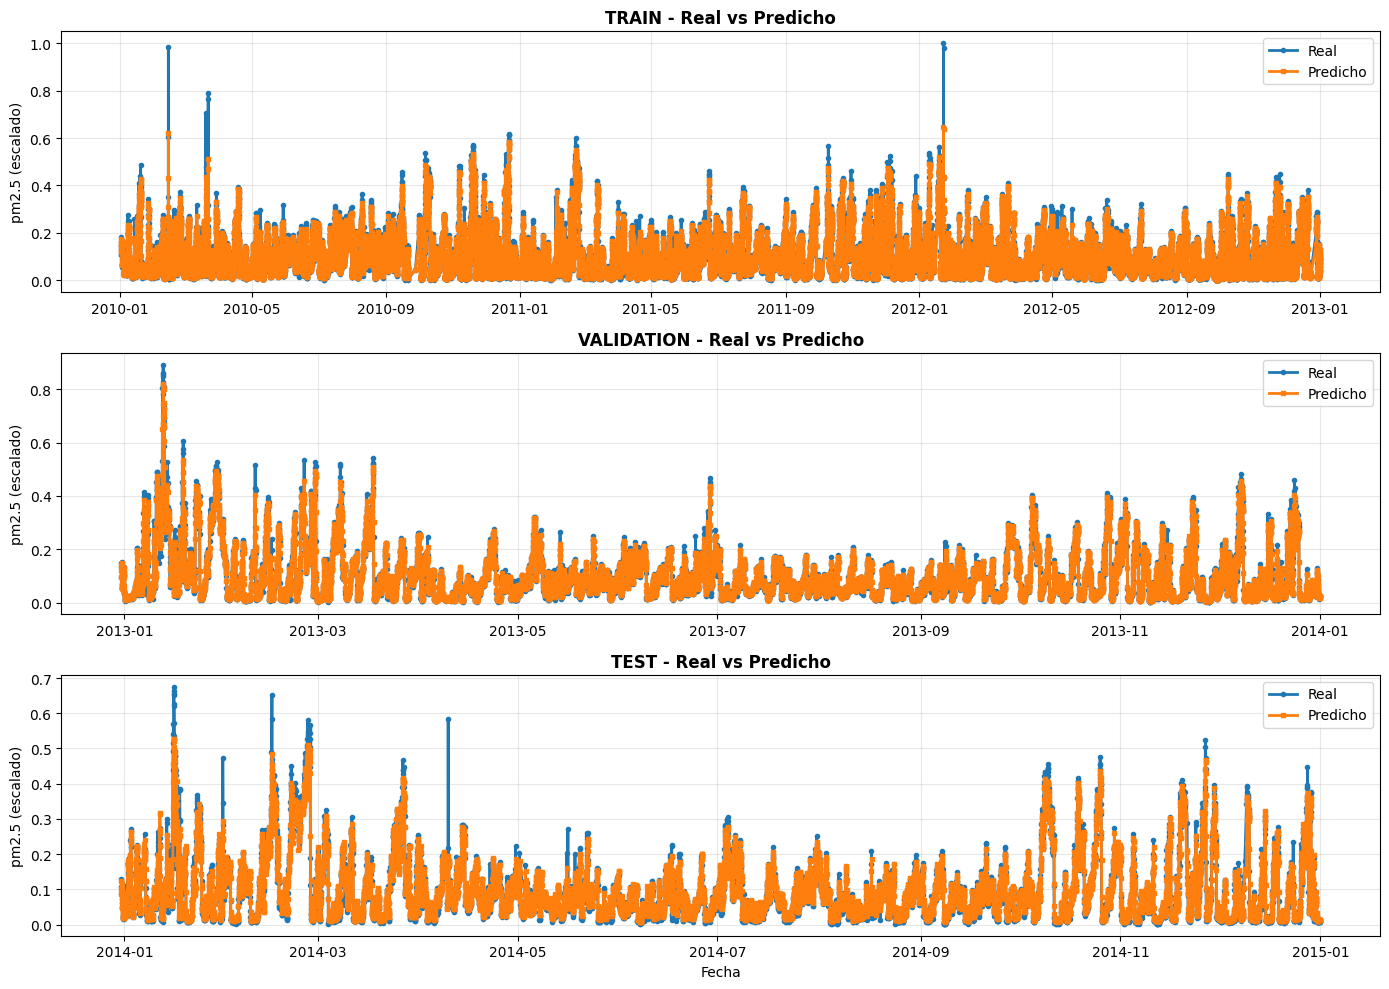


✓ Entrenamiento completado


In [86]:
# ==================== GRÁFICA ====================
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Train
axes[0].plot(y_train.index, y_train.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
axes[0].plot(y_train.index, y_train_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
axes[0].set_title('TRAIN - Real vs Predicho', fontsize=12, fontweight='bold')
axes[0].set_ylabel('pm2.5 (escalado)', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation
axes[1].plot(y_val.index, y_val.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
axes[1].plot(y_val.index, y_val_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
axes[1].set_title('VALIDATION - Real vs Predicho', fontsize=12, fontweight='bold')
axes[1].set_ylabel('pm2.5 (escalado)', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test
axes[2].plot(y_test.index, y_test.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
axes[2].plot(y_test.index, y_test_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
axes[2].set_title('TEST - Real vs Predicho', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Fecha', fontsize=10)
axes[2].set_ylabel('pm2.5 (escalado)', fontsize=10)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# ==================== GUARDAR FIGURA ====================
plt.savefig('../models/model_rf_h1/predicciones_h1.png', dpi=300, bbox_inches='tight')
print("✓ Figura guardada: predicciones_h1.png")

plt.show()

print("\n✓ Entrenamiento completado")

[I 2026-05-15 23:49:22,382] A new study created in memory with name: no-name-eb6c227a-f021-4b7d-bb5f-e1841f90cd7a



ENTRENAMIENTO DEL HORIZONTE 2


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-15 23:49:35,715] Trial 0 finished with value: 0.0019190938549156142 and parameters: {'n_estimators': 160, 'max_depth': 43, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.0019190938549156142.
[I 2026-05-15 23:50:13,781] Trial 1 finished with value: 0.001789239236325065 and parameters: {'n_estimators': 391, 'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.001789239236325065.
[I 2026-05-15 23:50:36,199] Trial 2 finished with value: 0.001985951521289371 and parameters: {'n_estimators': 339, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.001789239236325065.
[I 2026-05-15 23:51:13,097] Trial 3 finished with value: 0.001782596046912112 and parameters: {'n_estimators': 349, 'max_depth': 28, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 3 with valu

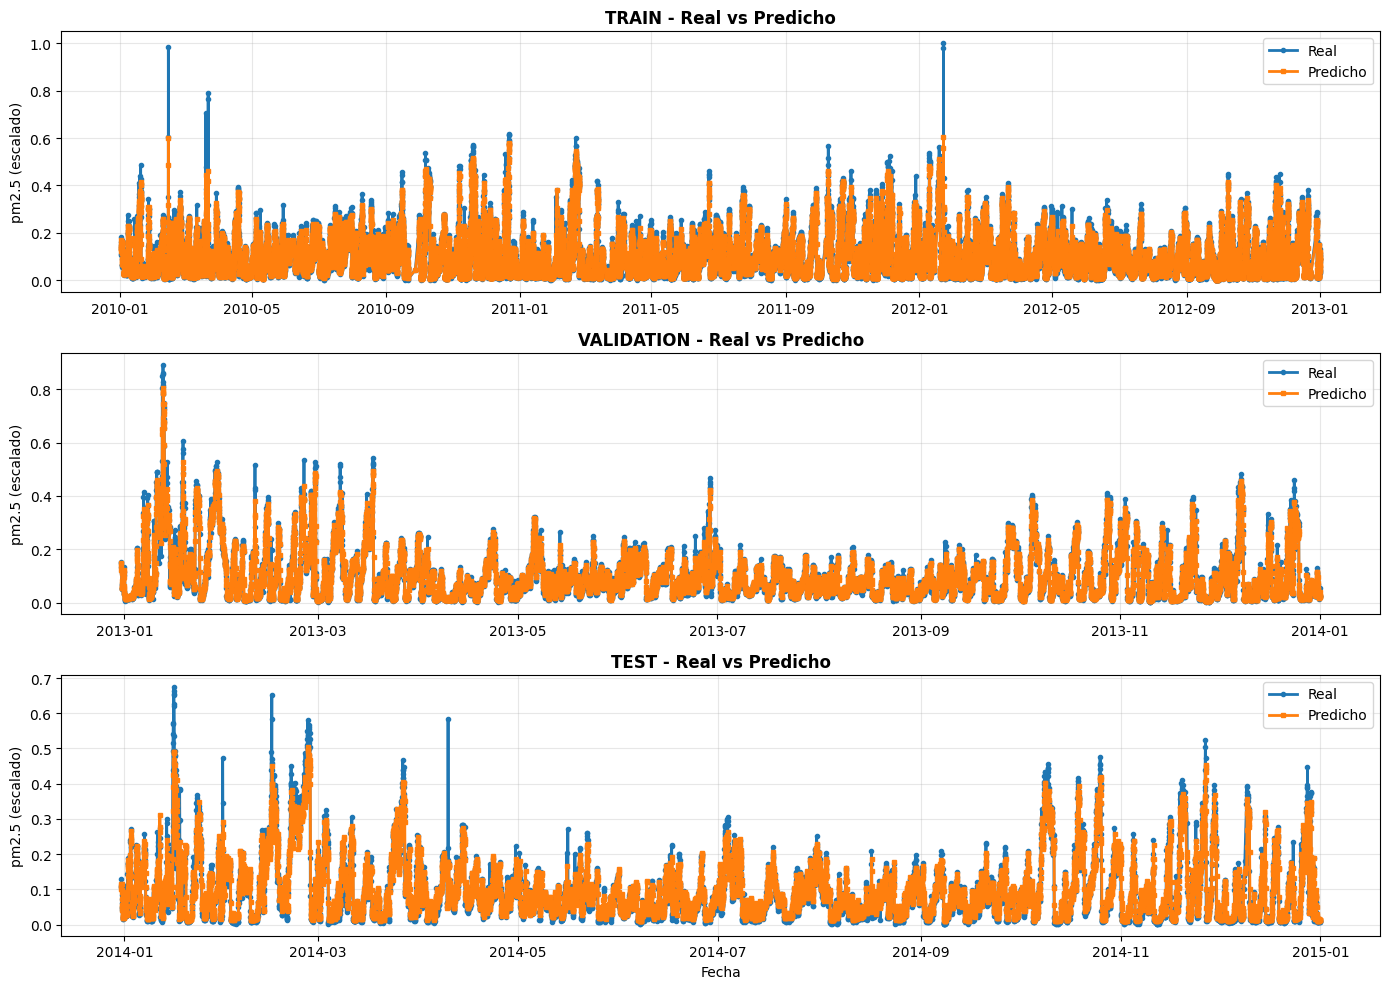

[I 2026-05-16 00:27:29,468] A new study created in memory with name: no-name-e9f00d80-58e6-4268-ac91-c070915e4443



✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 3


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 00:27:43,070] Trial 0 finished with value: 0.0025504467580305143 and parameters: {'n_estimators': 118, 'max_depth': 36, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.0025504467580305143.
[I 2026-05-16 00:28:12,113] Trial 1 finished with value: 0.002601506072402731 and parameters: {'n_estimators': 368, 'max_depth': 34, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.0025504467580305143.
[I 2026-05-16 00:28:38,073] Trial 2 finished with value: 0.0025964073904768243 and parameters: {'n_estimators': 301, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.0025504467580305143.
[I 2026-05-16 00:29:00,561] Trial 3 finished with value: 0.0025926033784813857 and parameters: {'n_estimators': 327, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with v

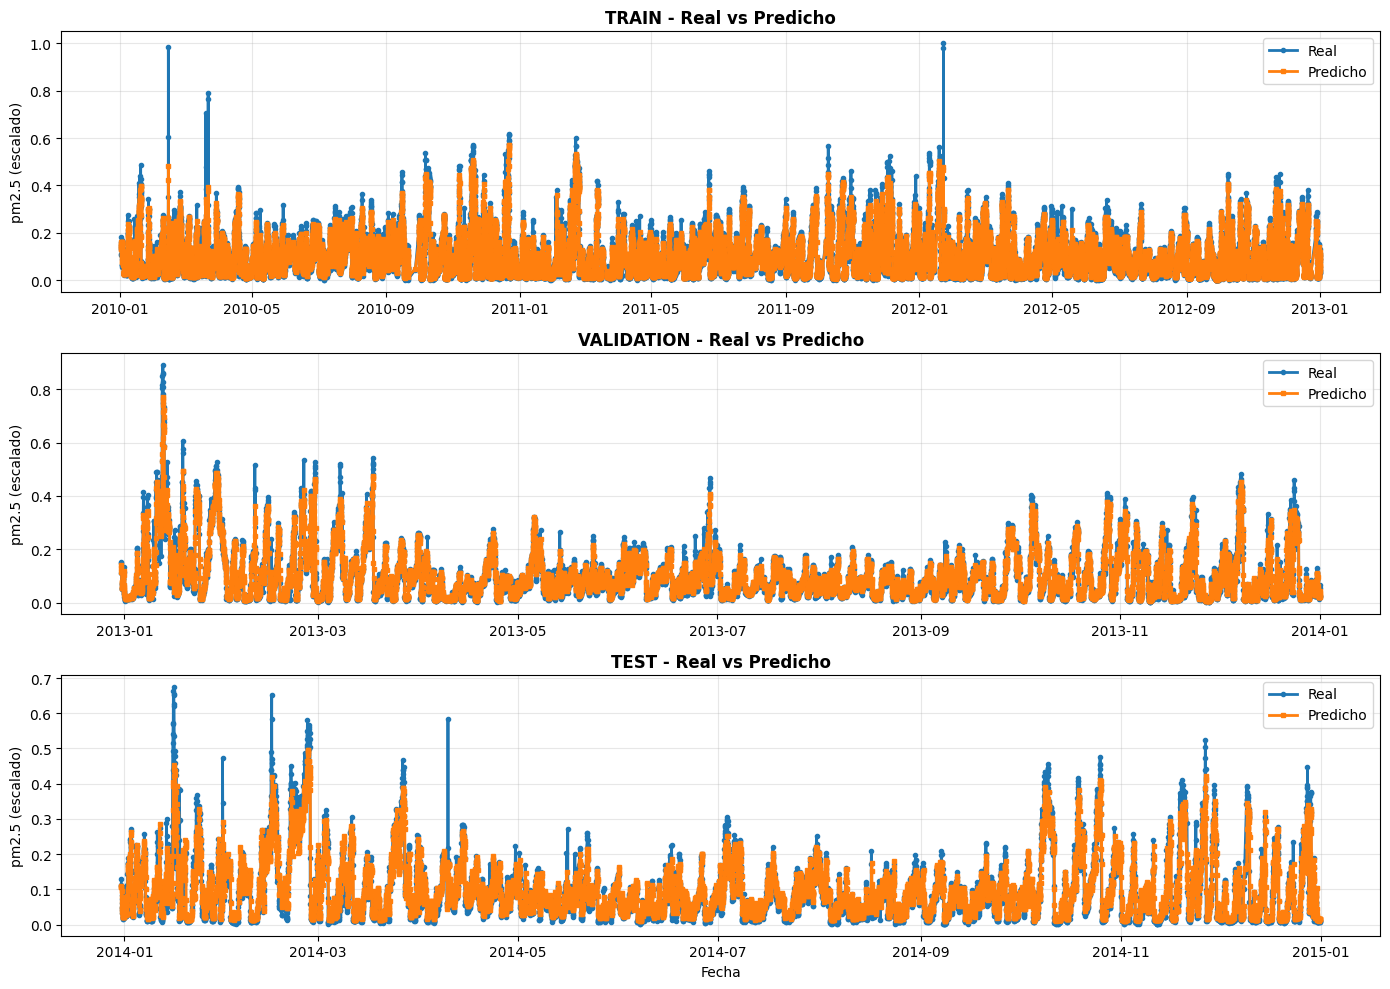

[I 2026-05-16 00:51:43,849] A new study created in memory with name: no-name-6a8e9bb1-ba08-496a-8596-1c1d710eb3f9



✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 4


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 00:51:55,509] Trial 0 finished with value: 0.0034410159749260695 and parameters: {'n_estimators': 248, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.0034410159749260695.
[I 2026-05-16 00:52:25,657] Trial 1 finished with value: 0.0030309065297254465 and parameters: {'n_estimators': 261, 'max_depth': 24, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.0030309065297254465.
[I 2026-05-16 00:52:53,849] Trial 2 finished with value: 0.0031501462670752785 and parameters: {'n_estimators': 335, 'max_depth': 41, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.0030309065297254465.
[I 2026-05-16 00:53:05,382] Trial 3 finished with value: 0.003224252943783992 and parameters: {'n_estimators': 167, 'max_depth': 9, 'min_samples_split': 19, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with va

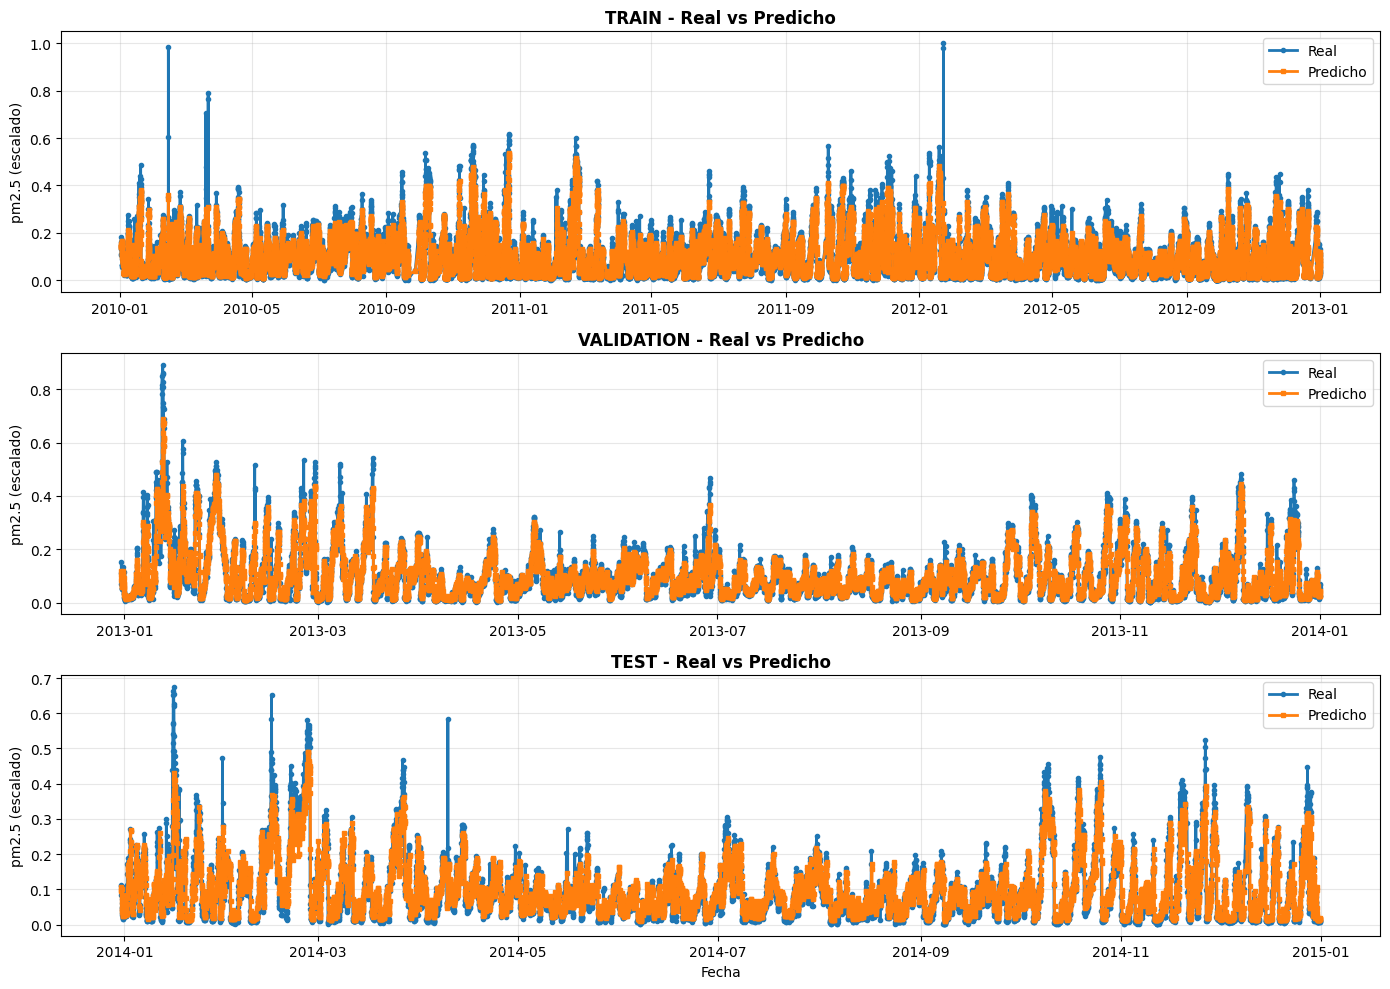

[I 2026-05-16 01:19:43,335] A new study created in memory with name: no-name-2ba27588-7756-4bb5-b495-288546a04126



✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 5


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 01:20:21,412] Trial 0 finished with value: 0.0036204060494233778 and parameters: {'n_estimators': 340, 'max_depth': 44, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.0036204060494233778.
[I 2026-05-16 01:20:27,174] Trial 1 finished with value: 0.003696564036120563 and parameters: {'n_estimators': 61, 'max_depth': 32, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.0036204060494233778.
[I 2026-05-16 01:21:25,183] Trial 2 finished with value: 0.0035612589291090543 and parameters: {'n_estimators': 416, 'max_depth': 37, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.0035612589291090543.
[I 2026-05-16 01:21:30,529] Trial 3 finished with value: 0.003730415501715439 and parameters: {'n_estimators': 86, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value:

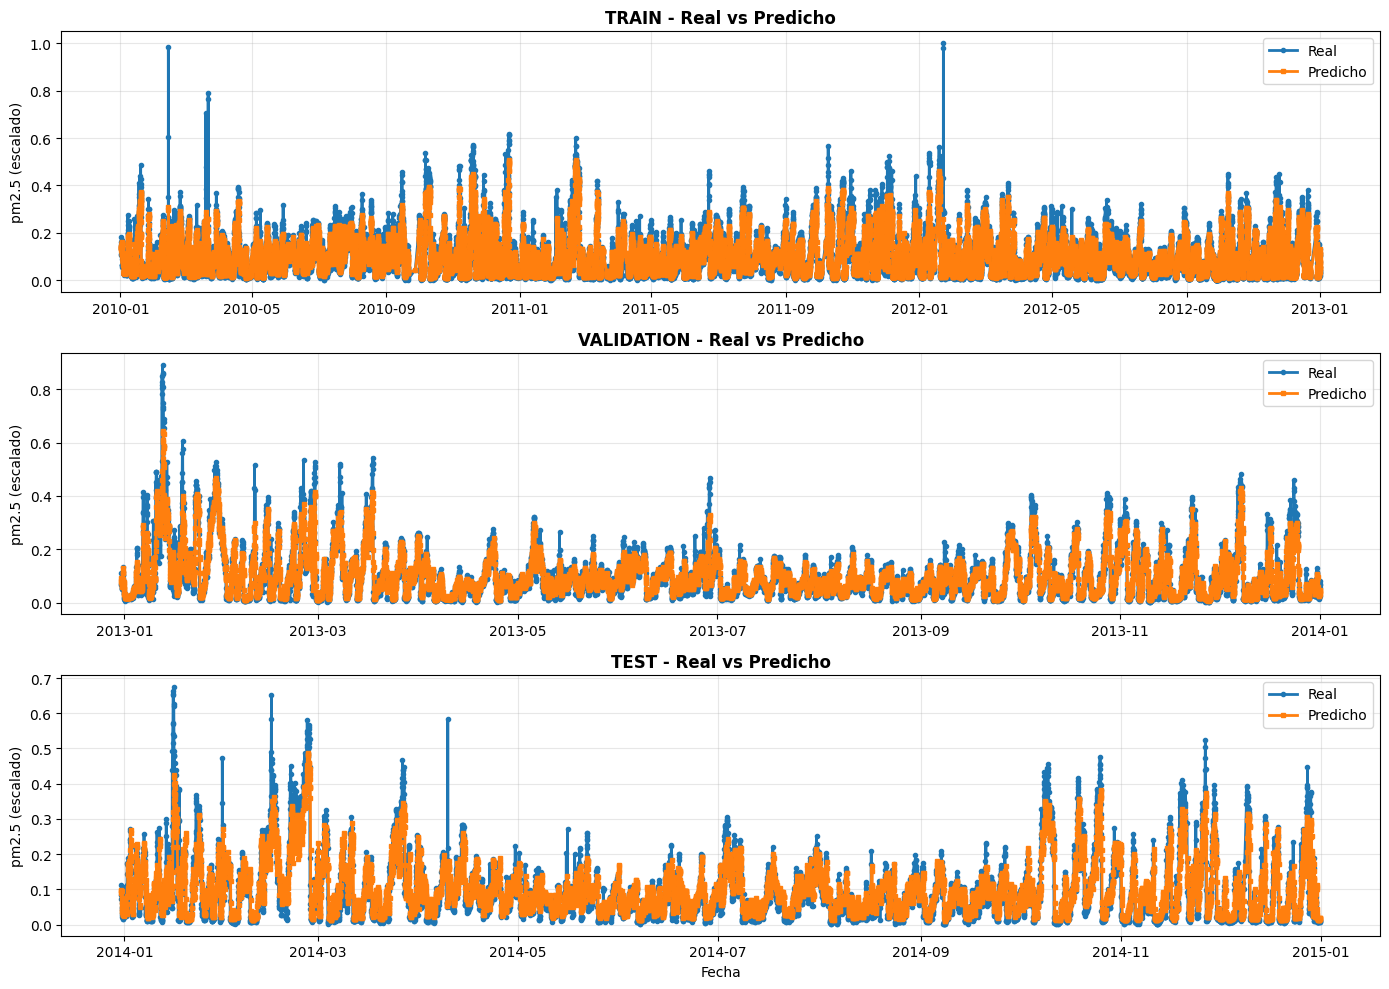

[I 2026-05-16 01:55:34,083] A new study created in memory with name: no-name-c18c1619-a4c4-423d-bab4-9a7a8c54f615



✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 6


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 01:55:51,269] Trial 0 finished with value: 0.004103256450778366 and parameters: {'n_estimators': 185, 'max_depth': 45, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.004103256450778366.
[I 2026-05-16 01:56:22,873] Trial 1 finished with value: 0.004035509686550645 and parameters: {'n_estimators': 312, 'max_depth': 47, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.004035509686550645.
[I 2026-05-16 01:56:30,276] Trial 2 finished with value: 0.004132674106596429 and parameters: {'n_estimators': 108, 'max_depth': 50, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 1 with value: 0.004035509686550645.
[I 2026-05-16 01:56:38,241] Trial 3 finished with value: 0.004103674043256009 and parameters: {'n_estimators': 84, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value:

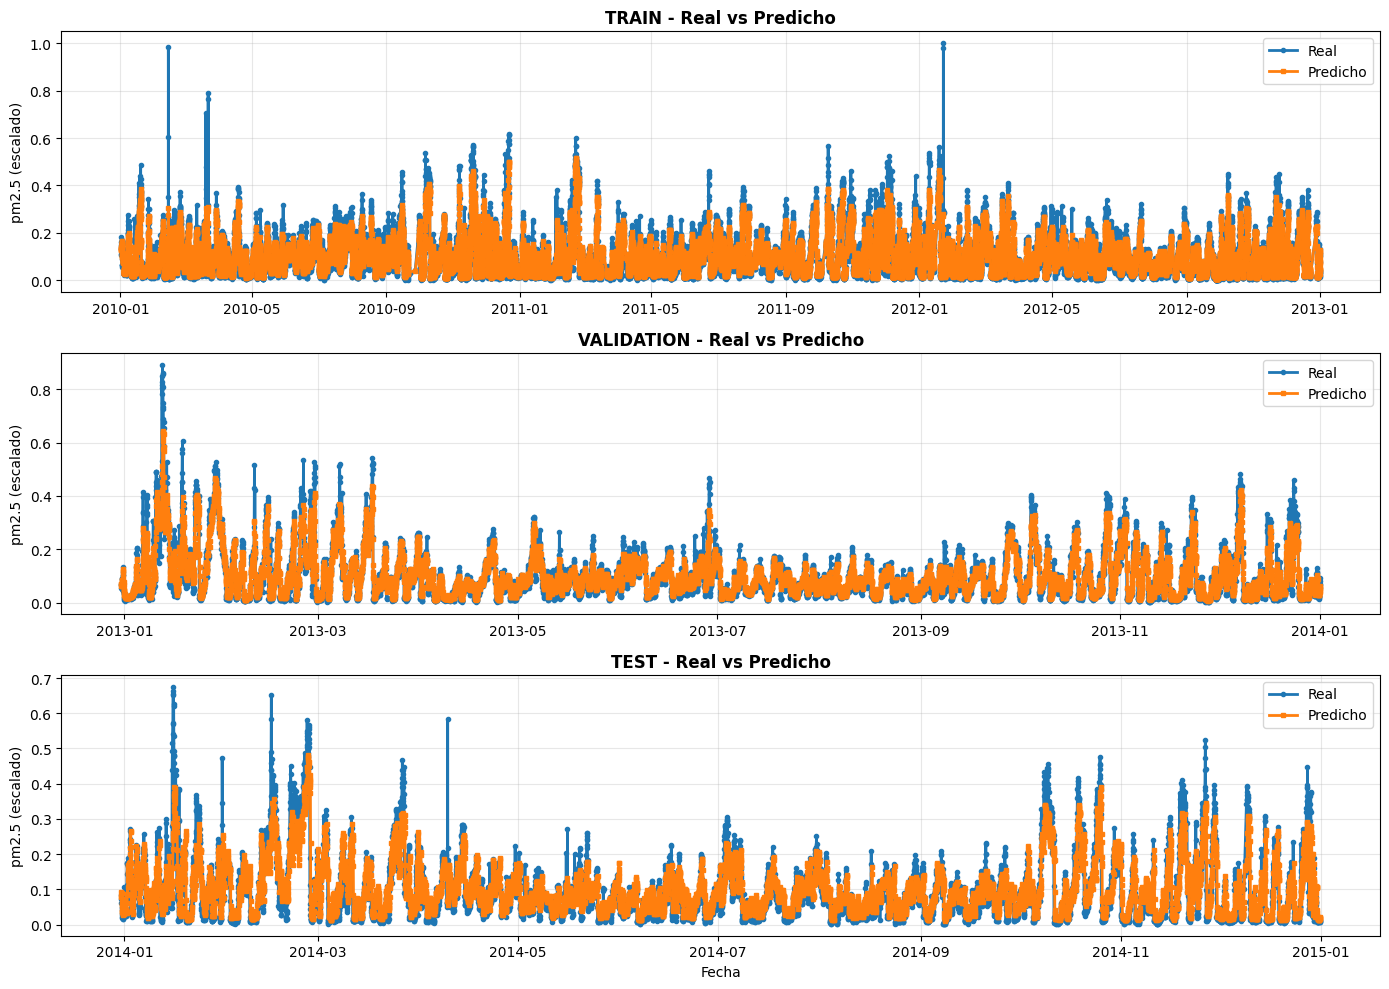


✓ Entrenamiento completado


In [89]:
import os

for i in range(2,7):

  print("\n" + "="*80)
  print(f"ENTRENAMIENTO DEL HORIZONTE {i}")
  print("="*80)

  #crear carpeta
  path = f'../models/model_rf_h{i}'
  os.makedirs(path, exist_ok=True)

  #Eliminando filas con target NaN, las X pueden tener faltantes para RF
  X = X_scaled.replace('NaN', np.nan)
  y = y_scaled_dict[f'h{i}'].replace('NaN', np.nan)
  valid_idx = y.notna().squeeze()
  X_clean = X[valid_idx]
  y_clean = y[valid_idx]

  #split data para entrenamiento primer horizonte

  train_end = '2012-12-31'
  val_end = '2013-12-31'

  X_train = X_clean.loc[:train_end]
  X_val = X_clean.loc[train_end:val_end]
  X_test = X_clean.loc[val_end:]

  y_train = y_clean.loc[:train_end]
  y_val = y_clean.loc[train_end:val_end]
  y_test = y_clean.loc[val_end:]

  # ==================== OPTUNA ====================
  study = optuna.create_study(direction='minimize', pruner=MedianPruner())
  study.optimize(objective, n_trials=50, show_progress_bar=True)

  best_params = study.best_params
  print(f"\n✓ Mejores parámetros:\n{best_params}")

  # ==================== ENTRENAR CON MEJORES PARÁMETROS ====================
  X_train_val = pd.concat([X_train, X_val])
  y_train_val = pd.concat([y_train, y_val])

  model_final = RandomForestRegressor(**best_params, random_state=42)
  model_final.fit(X_train_val, y_train_val.values.ravel())

  # ==================== GUARDAR MODELO ====================
  joblib.dump(model_final, f'{path}/model_rf_h{i}.joblib')
  print("✓ Modelo guardado: model_rf_h1.joblib")

  # ==================== CARGAR DESPUÉS ====================
  # model_loaded = joblib.load('/content/drive/MyDrive/AI_Bootcamp/Models/model_rf_h1.joblib')
  # y_pred = model_loaded.predict(X_test)

  # ==================== PREDICCIONES ====================
  y_train_pred = model_final.predict(X_train)
  y_val_pred = model_final.predict(X_val)
  y_test_pred = model_final.predict(X_test)

  # ==================== MÉTRICAS ====================
  metrics_train = calculate_metrics(y_train.values.ravel(), y_train_pred, 'Train')
  metrics_val = calculate_metrics(y_val.values.ravel(), y_val_pred, 'Validation')
  metrics_test = calculate_metrics(y_test.values.ravel(), y_test_pred, 'Test')

  # ==================== GUARDAR COMO CSV ====================
  metrics_df = pd.DataFrame([metrics_train, metrics_val, metrics_test])

  metrics_df.to_csv(f'{path}/metrics_h{i}.csv', index=False)
  print(f"✓ Métricas guardadas: metrics_h{i}.csv")

  # ==================== TABLAS DE MÉTRICAS ====================
  print("\n" + "="*80)
  print("MÉTRICAS - TRAIN")
  print("="*80)
  metrics_train_df = pd.DataFrame([metrics_train])
  print(metrics_train_df.to_string(index=False))

  print("\n" + "="*80)
  print("MÉTRICAS - VALIDATION")
  print("="*80)
  metrics_val_df = pd.DataFrame([metrics_val])
  print(metrics_val_df.to_string(index=False))

  print("\n" + "="*80)
  print("MÉTRICAS - TEST")
  print("="*80)
  metrics_test_df = pd.DataFrame([metrics_test])
  print(metrics_test_df.to_string(index=False))

  # ==================== CSV CON PREDICCIONES ====================
  results_train = pd.DataFrame({
      'real': y_train.values.ravel(),
      'predicho': y_train_pred,
      'set': 'train'
  }, index=y_train.index)

  results_val = pd.DataFrame({
      'real': y_val.values.ravel(),
      'predicho': y_val_pred,
      'set': 'validation'
  }, index=y_val.index)

  results_test = pd.DataFrame({
      'real': y_test.values.ravel(),
      'predicho': y_test_pred,
      'set': 'test'
  }, index=y_test.index)

  results_all = pd.concat([results_train, results_val, results_test])
  results_all.to_csv(f'{path}/predicciones_h{i}.csv')
  print(f"\n✓ CSV guardado: predicciones_h{i}.csv")

  # ==================== GRÁFICA ====================
  fig, axes = plt.subplots(3, 1, figsize=(14, 10))

  # Train
  axes[0].plot(y_train.index, y_train.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[0].plot(y_train.index, y_train_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[0].set_title('TRAIN - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[0].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  # Validation
  axes[1].plot(y_val.index, y_val.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[1].plot(y_val.index, y_val_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[1].set_title('VALIDATION - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[1].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  # Test
  axes[2].plot(y_test.index, y_test.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[2].plot(y_test.index, y_test_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[2].set_title('TEST - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[2].set_xlabel('Fecha', fontsize=10)
  axes[2].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[2].legend()
  axes[2].grid(True, alpha=0.3)

  plt.tight_layout()
  # ==================== GUARDAR FIGURA ====================
  plt.savefig(f'{path}/predicciones_h{i}.png', dpi=300, bbox_inches='tight')
  print(f"✓ Figura guardada: predicciones_h{i}.png")

  plt.show()

  print("\n✓ Entrenamiento completado")


[I 2026-05-15 23:49:22,382] A new study created in memory with name: no-name-eb6c227a-f021-4b7d-bb5f-e1841f90cd7a



ENTRENAMIENTO DEL HORIZONTE 2


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-15 23:49:35,715] Trial 0 finished with value: 0.0019190938549156142 and parameters: {'n_estimators': 160, 'max_depth': 43, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.0019190938549156142.
[I 2026-05-15 23:50:13,781] Trial 1 finished with value: 0.001789239236325065 and parameters: {'n_estimators': 391, 'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.001789239236325065.
[I 2026-05-15 23:50:36,199] Trial 2 finished with value: 0.001985951521289371 and parameters: {'n_estimators': 339, 'max_depth': 11, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.001789239236325065.
[I 2026-05-15 23:51:13,097] Trial 3 finished with value: 0.001782596046912112 and parameters: {'n_estimators': 349, 'max_depth': 28, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 3 with valu

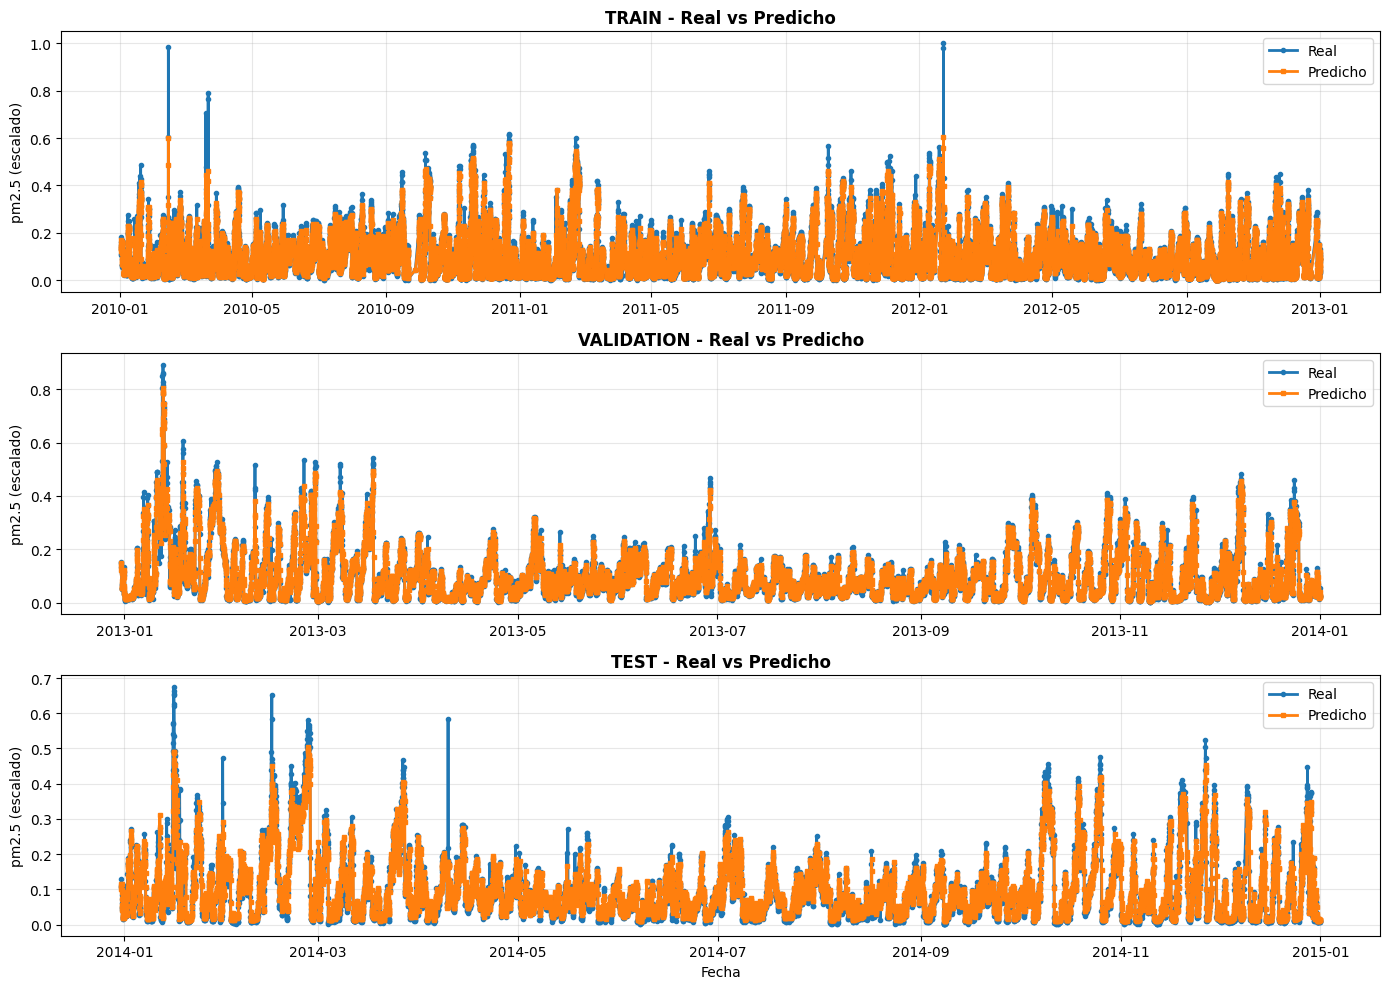

[I 2026-05-16 00:27:29,468] A new study created in memory with name: no-name-e9f00d80-58e6-4268-ac91-c070915e4443



✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 3


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 00:27:43,070] Trial 0 finished with value: 0.0025504467580305143 and parameters: {'n_estimators': 118, 'max_depth': 36, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.0025504467580305143.
[I 2026-05-16 00:28:12,113] Trial 1 finished with value: 0.002601506072402731 and parameters: {'n_estimators': 368, 'max_depth': 34, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.0025504467580305143.
[I 2026-05-16 00:28:38,073] Trial 2 finished with value: 0.0025964073904768243 and parameters: {'n_estimators': 301, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.0025504467580305143.
[I 2026-05-16 00:29:00,561] Trial 3 finished with value: 0.0025926033784813857 and parameters: {'n_estimators': 327, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with v

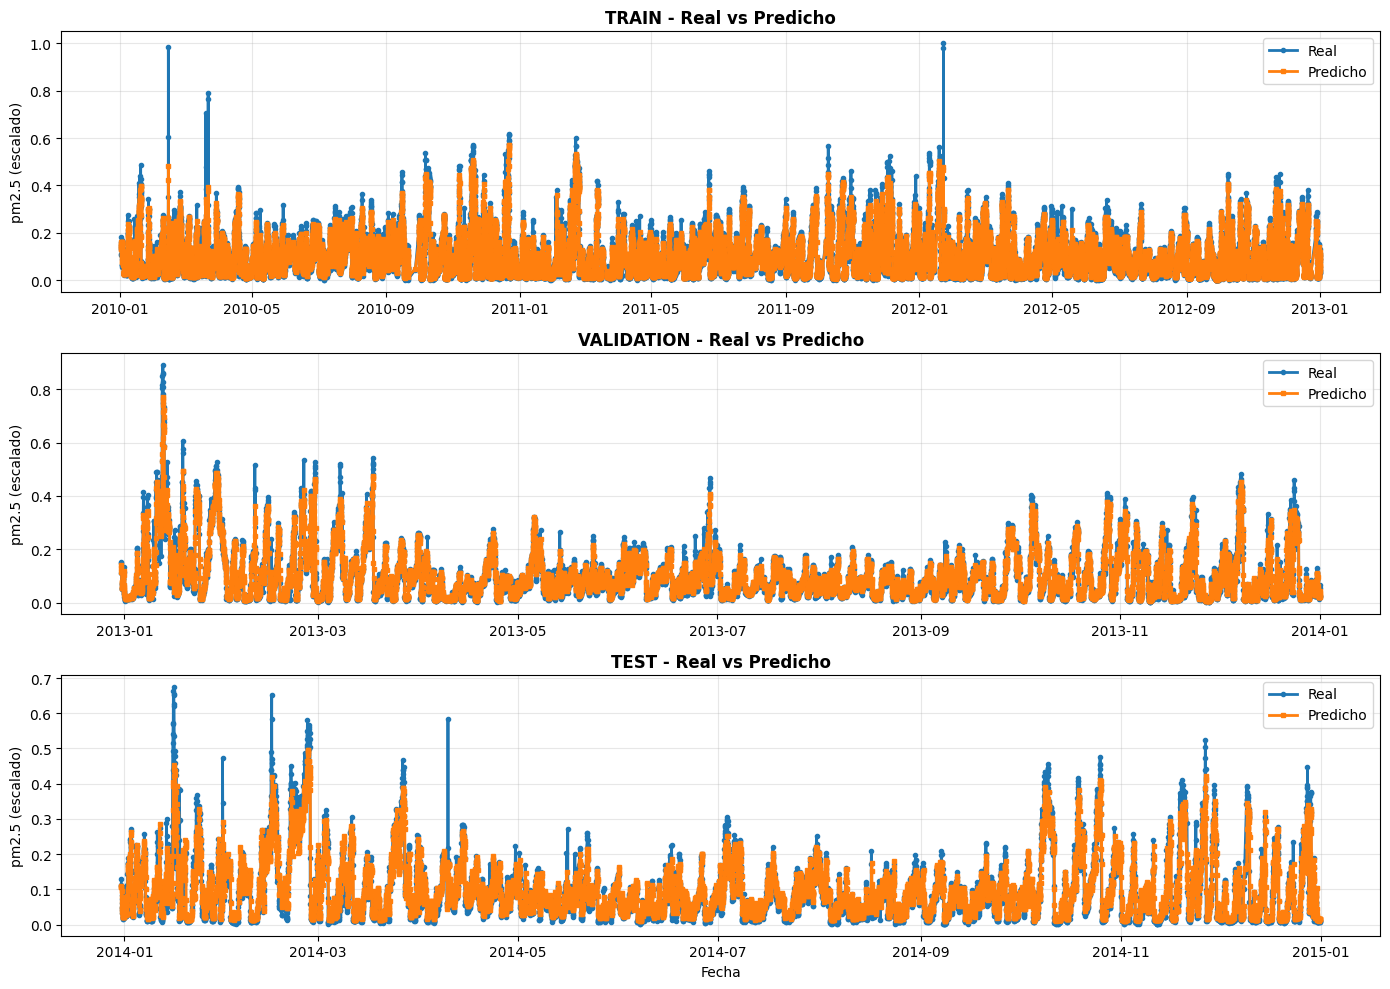

[I 2026-05-16 00:51:43,849] A new study created in memory with name: no-name-6a8e9bb1-ba08-496a-8596-1c1d710eb3f9



✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 4


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 00:51:55,509] Trial 0 finished with value: 0.0034410159749260695 and parameters: {'n_estimators': 248, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.0034410159749260695.
[I 2026-05-16 00:52:25,657] Trial 1 finished with value: 0.0030309065297254465 and parameters: {'n_estimators': 261, 'max_depth': 24, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.0030309065297254465.
[I 2026-05-16 00:52:53,849] Trial 2 finished with value: 0.0031501462670752785 and parameters: {'n_estimators': 335, 'max_depth': 41, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value: 0.0030309065297254465.
[I 2026-05-16 00:53:05,382] Trial 3 finished with value: 0.003224252943783992 and parameters: {'n_estimators': 167, 'max_depth': 9, 'min_samples_split': 19, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with va

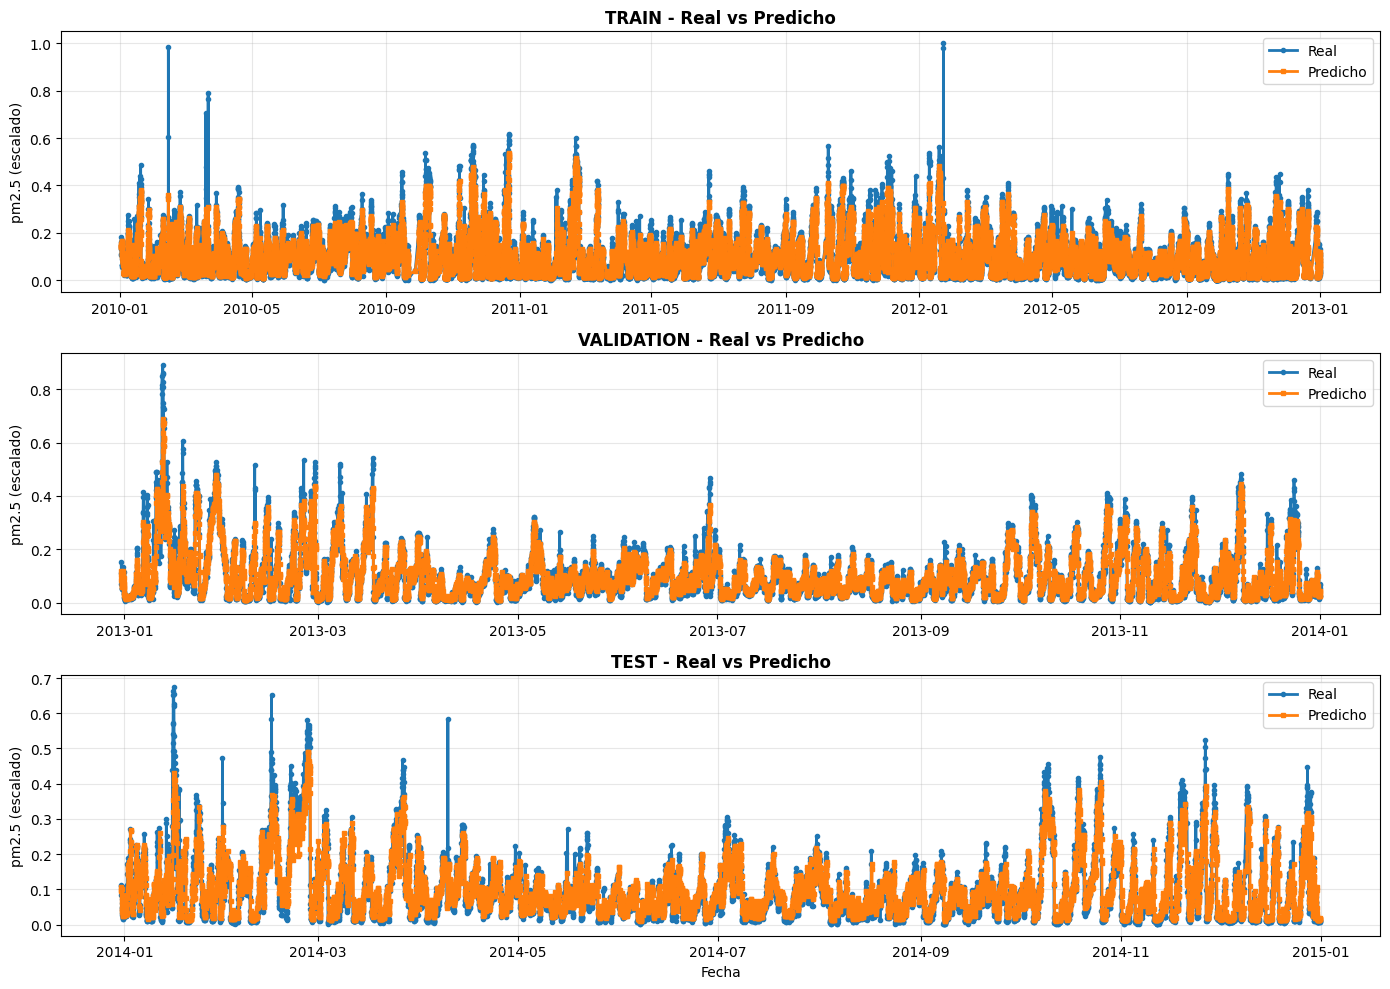

[I 2026-05-16 01:19:43,335] A new study created in memory with name: no-name-2ba27588-7756-4bb5-b495-288546a04126



✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 5


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 01:20:21,412] Trial 0 finished with value: 0.0036204060494233778 and parameters: {'n_estimators': 340, 'max_depth': 44, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.0036204060494233778.
[I 2026-05-16 01:20:27,174] Trial 1 finished with value: 0.003696564036120563 and parameters: {'n_estimators': 61, 'max_depth': 32, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.0036204060494233778.
[I 2026-05-16 01:21:25,183] Trial 2 finished with value: 0.0035612589291090543 and parameters: {'n_estimators': 416, 'max_depth': 37, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.0035612589291090543.
[I 2026-05-16 01:21:30,529] Trial 3 finished with value: 0.003730415501715439 and parameters: {'n_estimators': 86, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value:

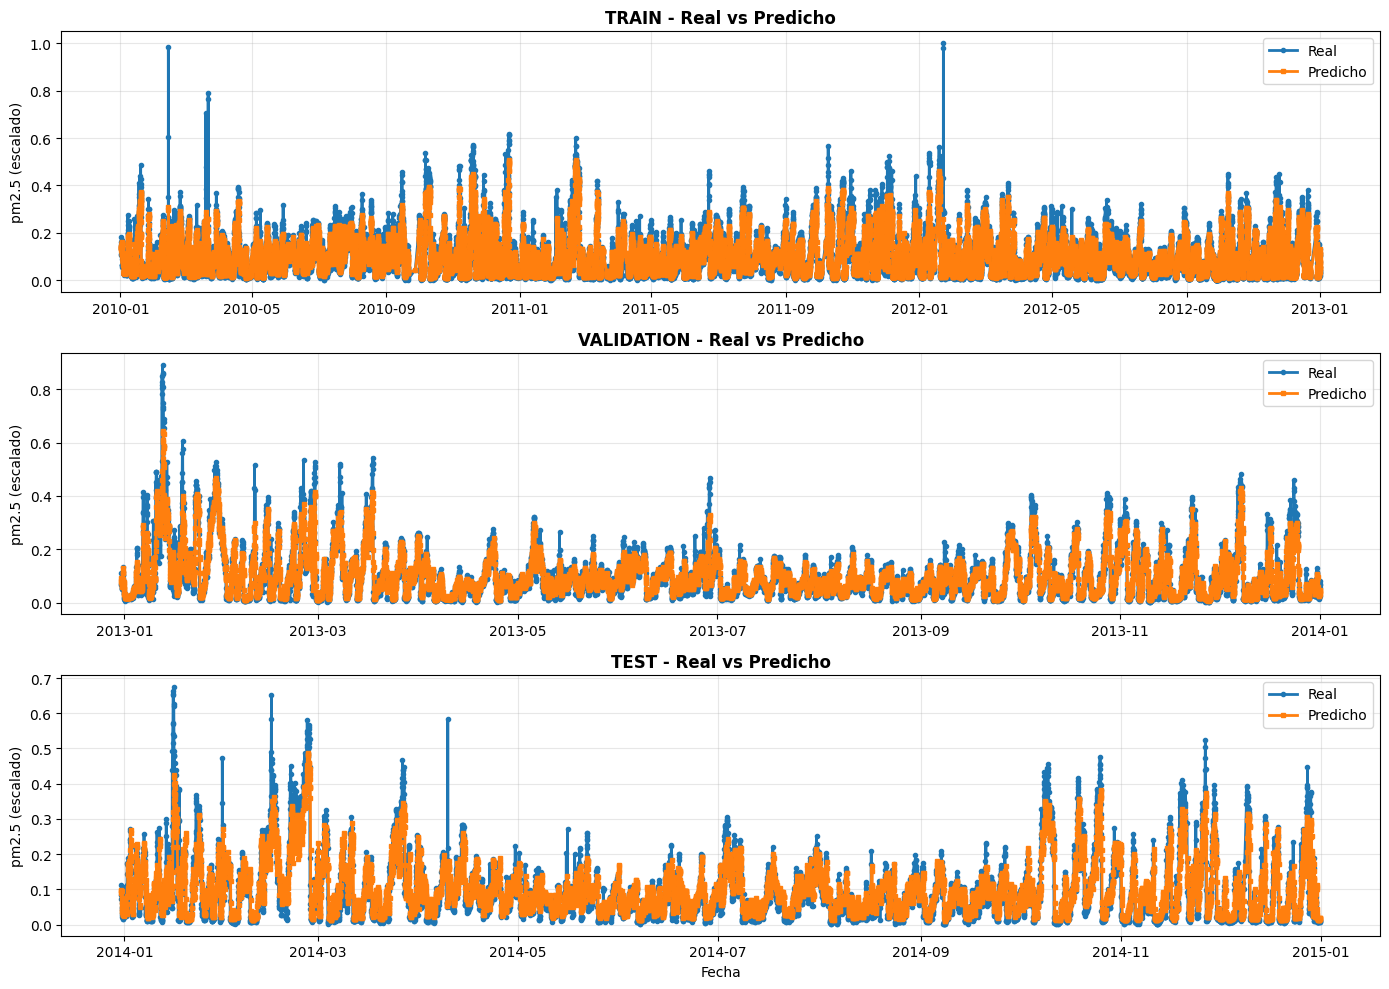

[I 2026-05-16 01:55:34,083] A new study created in memory with name: no-name-c18c1619-a4c4-423d-bab4-9a7a8c54f615



✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 6


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 01:55:51,269] Trial 0 finished with value: 0.004103256450778366 and parameters: {'n_estimators': 185, 'max_depth': 45, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.004103256450778366.
[I 2026-05-16 01:56:22,873] Trial 1 finished with value: 0.004035509686550645 and parameters: {'n_estimators': 312, 'max_depth': 47, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.004035509686550645.
[I 2026-05-16 01:56:30,276] Trial 2 finished with value: 0.004132674106596429 and parameters: {'n_estimators': 108, 'max_depth': 50, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 1 with value: 0.004035509686550645.
[I 2026-05-16 01:56:38,241] Trial 3 finished with value: 0.004103674043256009 and parameters: {'n_estimators': 84, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 1 with value:

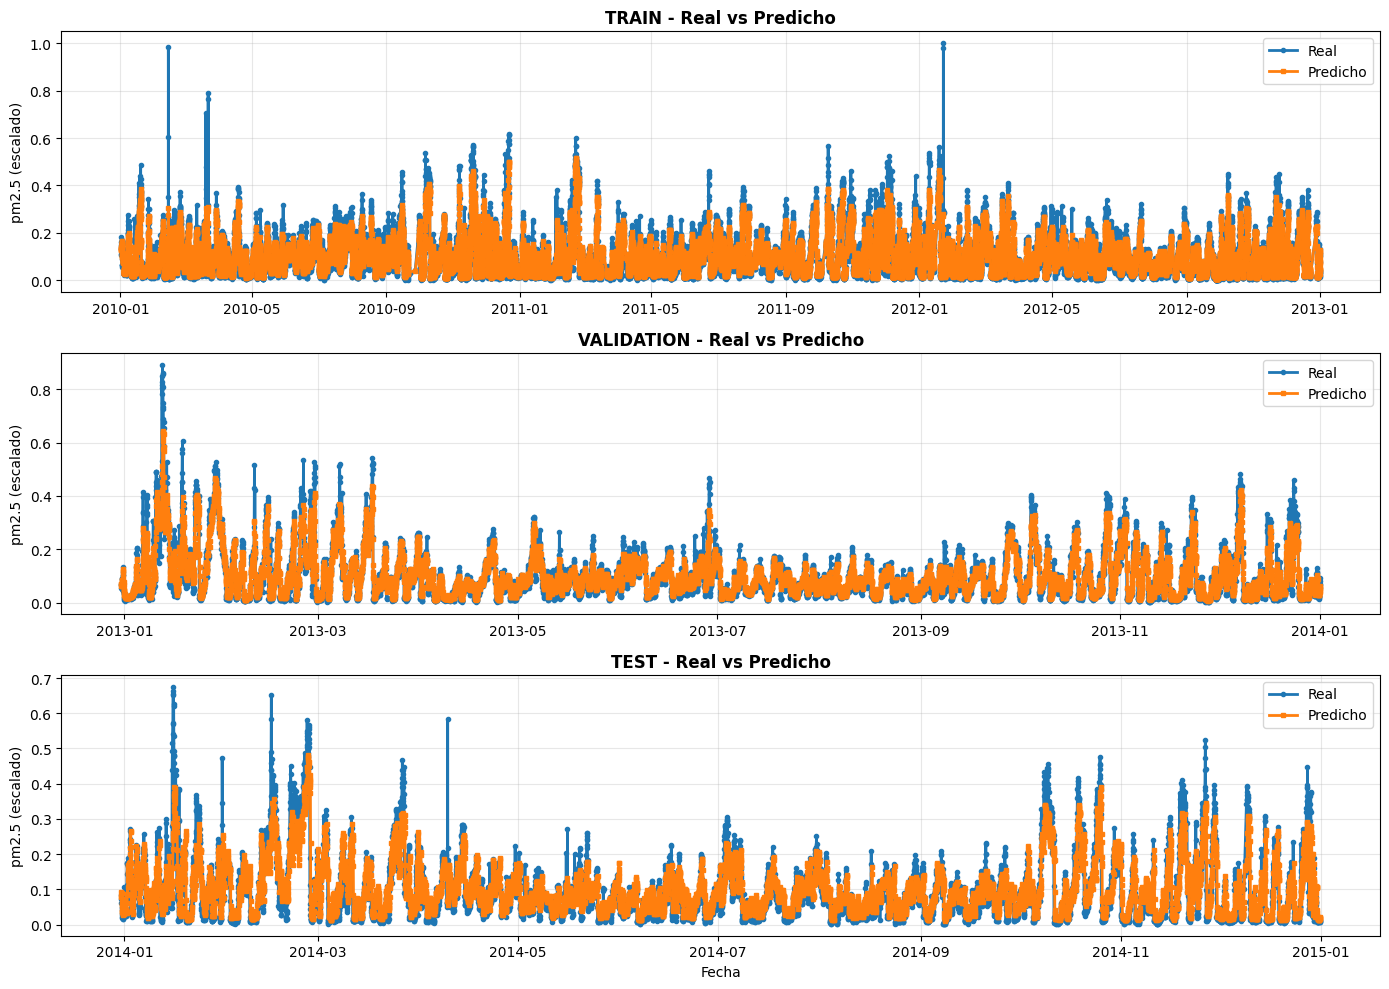


✓ Entrenamiento completado


In [ ]:
import os

for i in range(7,8):

  print("\n" + "="*80)
  print(f"ENTRENAMIENTO DEL HORIZONTE {i}")
  print("="*80)

  #crear carpeta
  path = f'../models/model_rf_h{i}'
  os.makedirs(path, exist_ok=True)

  #Eliminando filas con target NaN, las X pueden tener faltantes para RF
  X = X_scaled.replace('NaN', np.nan)
  y = y_scaled_dict[f'h{i}'].replace('NaN', np.nan)
  valid_idx = y.notna().squeeze()
  X_clean = X[valid_idx]
  y_clean = y[valid_idx]

  #split data para entrenamiento primer horizonte

  train_end = '2012-12-31'
  val_end = '2013-12-31'

  X_train = X_clean.loc[:train_end]
  X_val = X_clean.loc[train_end:val_end]
  X_test = X_clean.loc[val_end:]

  y_train = y_clean.loc[:train_end]
  y_val = y_clean.loc[train_end:val_end]
  y_test = y_clean.loc[val_end:]

  # ==================== OPTUNA ====================
  study = optuna.create_study(direction='minimize', pruner=MedianPruner())
  study.optimize(objective, n_trials=50, show_progress_bar=True)

  best_params = study.best_params
  print(f"\n✓ Mejores parámetros:\n{best_params}")

  # ==================== ENTRENAR CON MEJORES PARÁMETROS ====================
  X_train_val = pd.concat([X_train, X_val])
  y_train_val = pd.concat([y_train, y_val])

  model_final = RandomForestRegressor(**best_params, random_state=42)
  model_final.fit(X_train_val, y_train_val.values.ravel())

  # ==================== GUARDAR MODELO ====================
  joblib.dump(model_final, f'{path}/model_rf_h{i}.joblib')
  print("✓ Modelo guardado: model_rf_h1.joblib")

  # ==================== CARGAR DESPUÉS ====================
  # model_loaded = joblib.load('/content/drive/MyDrive/AI_Bootcamp/Models/model_rf_h1.joblib')
  # y_pred = model_loaded.predict(X_test)

  # ==================== PREDICCIONES ====================
  y_train_pred = model_final.predict(X_train)
  y_val_pred = model_final.predict(X_val)
  y_test_pred = model_final.predict(X_test)

  # ==================== MÉTRICAS ====================
  metrics_train = calculate_metrics(y_train.values.ravel(), y_train_pred, 'Train')
  metrics_val = calculate_metrics(y_val.values.ravel(), y_val_pred, 'Validation')
  metrics_test = calculate_metrics(y_test.values.ravel(), y_test_pred, 'Test')

  # ==================== GUARDAR COMO CSV ====================
  metrics_df = pd.DataFrame([metrics_train, metrics_val, metrics_test])

  metrics_df.to_csv(f'{path}/metrics_h{i}.csv', index=False)
  print(f"✓ Métricas guardadas: metrics_h{i}.csv")

  # ==================== TABLAS DE MÉTRICAS ====================
  print("\n" + "="*80)
  print("MÉTRICAS - TRAIN")
  print("="*80)
  metrics_train_df = pd.DataFrame([metrics_train])
  print(metrics_train_df.to_string(index=False))

  print("\n" + "="*80)
  print("MÉTRICAS - VALIDATION")
  print("="*80)
  metrics_val_df = pd.DataFrame([metrics_val])
  print(metrics_val_df.to_string(index=False))

  print("\n" + "="*80)
  print("MÉTRICAS - TEST")
  print("="*80)
  metrics_test_df = pd.DataFrame([metrics_test])
  print(metrics_test_df.to_string(index=False))

  # ==================== CSV CON PREDICCIONES ====================
  results_train = pd.DataFrame({
      'real': y_train.values.ravel(),
      'predicho': y_train_pred,
      'set': 'train'
  }, index=y_train.index)

  results_val = pd.DataFrame({
      'real': y_val.values.ravel(),
      'predicho': y_val_pred,
      'set': 'validation'
  }, index=y_val.index)

  results_test = pd.DataFrame({
      'real': y_test.values.ravel(),
      'predicho': y_test_pred,
      'set': 'test'
  }, index=y_test.index)

  results_all = pd.concat([results_train, results_val, results_test])
  results_all.to_csv(f'{path}/predicciones_h{i}.csv')
  print(f"\n✓ CSV guardado: predicciones_h{i}.csv")

  # ==================== GRÁFICA ====================
  fig, axes = plt.subplots(3, 1, figsize=(14, 10))

  # Train
  axes[0].plot(y_train.index, y_train.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[0].plot(y_train.index, y_train_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[0].set_title('TRAIN - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[0].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  # Validation
  axes[1].plot(y_val.index, y_val.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[1].plot(y_val.index, y_val_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[1].set_title('VALIDATION - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[1].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  # Test
  axes[2].plot(y_test.index, y_test.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[2].plot(y_test.index, y_test_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[2].set_title('TEST - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[2].set_xlabel('Fecha', fontsize=10)
  axes[2].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[2].legend()
  axes[2].grid(True, alpha=0.3)

  plt.tight_layout()
  # ==================== GUARDAR FIGURA ====================
  plt.savefig(f'{path}/predicciones_h{i}.png', dpi=300, bbox_inches='tight')
  print(f"✓ Figura guardada: predicciones_h{i}.png")

  plt.show()

  print("\n✓ Entrenamiento completado")


[I 2026-05-16 02:35:22,285] A new study created in memory with name: no-name-52bc1f87-b898-4f30-a1a0-ce68a3e30d85



ENTRENAMIENTO DEL HORIZONTE 1


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-05-16 02:36:12,151] Trial 0 finished with value: 0.0010457226005008292 and parameters: {'n_estimators': 476, 'max_depth': 14, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.0010457226005008292.
[I 2026-05-16 02:36:37,310] Trial 1 finished with value: 0.0012953021864266995 and parameters: {'n_estimators': 368, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.0010457226005008292.
[I 2026-05-16 02:37:01,802] Trial 2 finished with value: 0.0014108433528895244 and parameters: {'n_estimators': 481, 'max_depth': 9, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.0010457226005008292.
[I 2026-05-16 02:37:30,083] Trial 3 finished with value: 0.0010010442187712474 and parameters: {'n_estimators': 202, 'max_depth': 49, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 3 with 

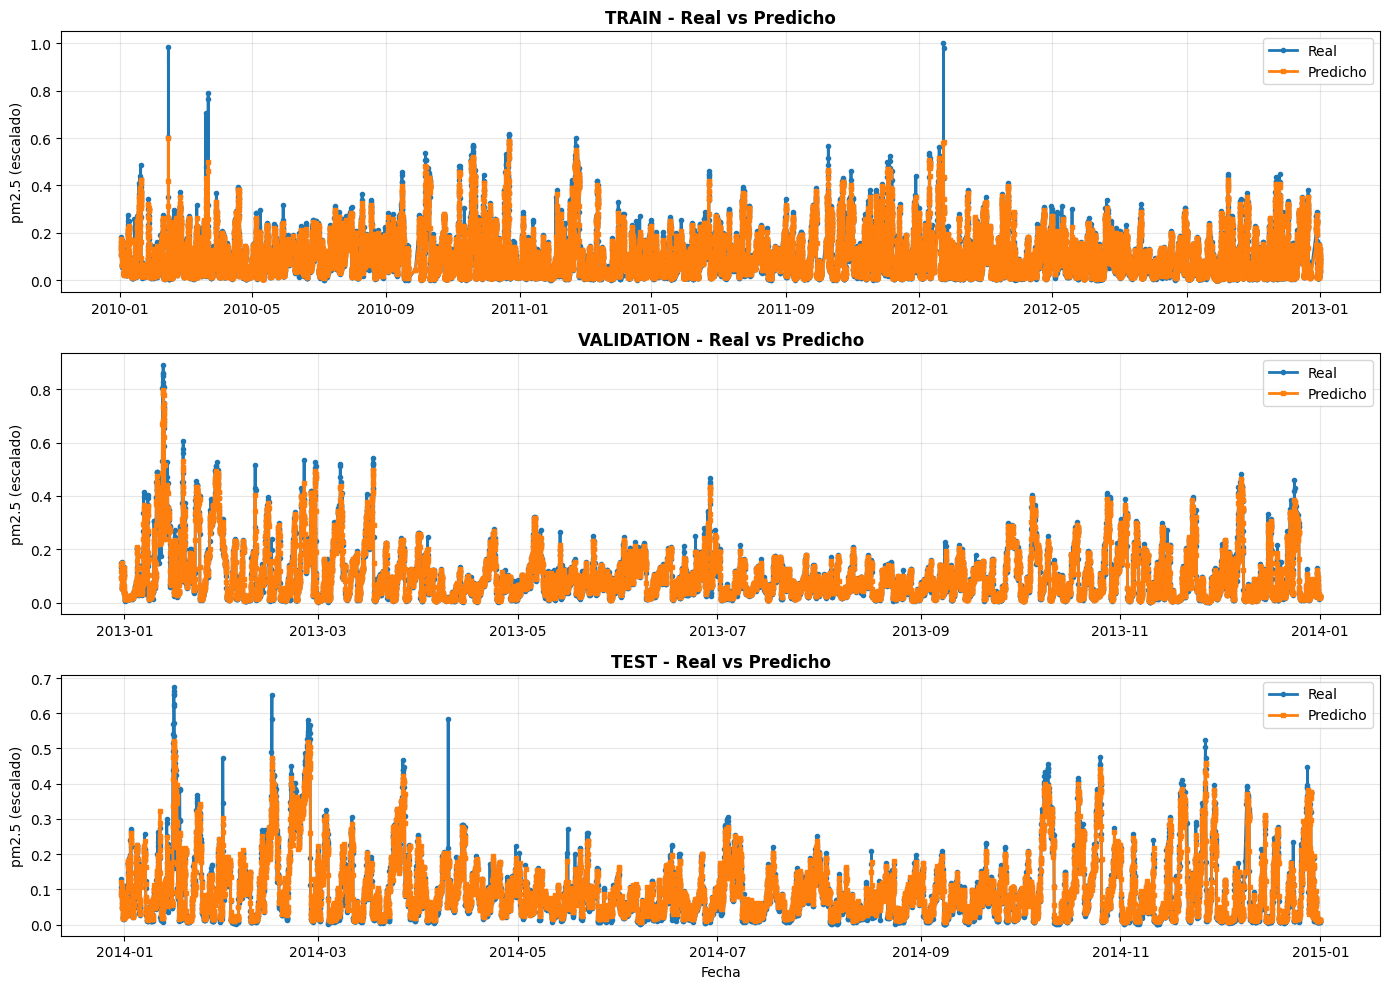


✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 2


[I 2026-05-16 04:41:50,646] A new study created in memory with name: no-name-3185b6a1-464d-492b-82b1-8c09cb89fa4e


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-05-16 04:41:57,139] Trial 0 finished with value: 0.0017809032480741898 and parameters: {'n_estimators': 61, 'max_depth': 50, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.0017809032480741898.
[I 2026-05-16 04:42:24,948] Trial 1 finished with value: 0.0019027621455186626 and parameters: {'n_estimators': 306, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.0017809032480741898.
[I 2026-05-16 04:42:41,230] Trial 2 finished with value: 0.001959686718915142 and parameters: {'n_estimators': 217, 'max_depth': 34, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.0017809032480741898.
[I 2026-05-16 04:42:59,350] Trial 3 finished with value: 0.0018812431524122474 and parameters: {'n_estimators': 186, 'max_depth': 38, 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with v

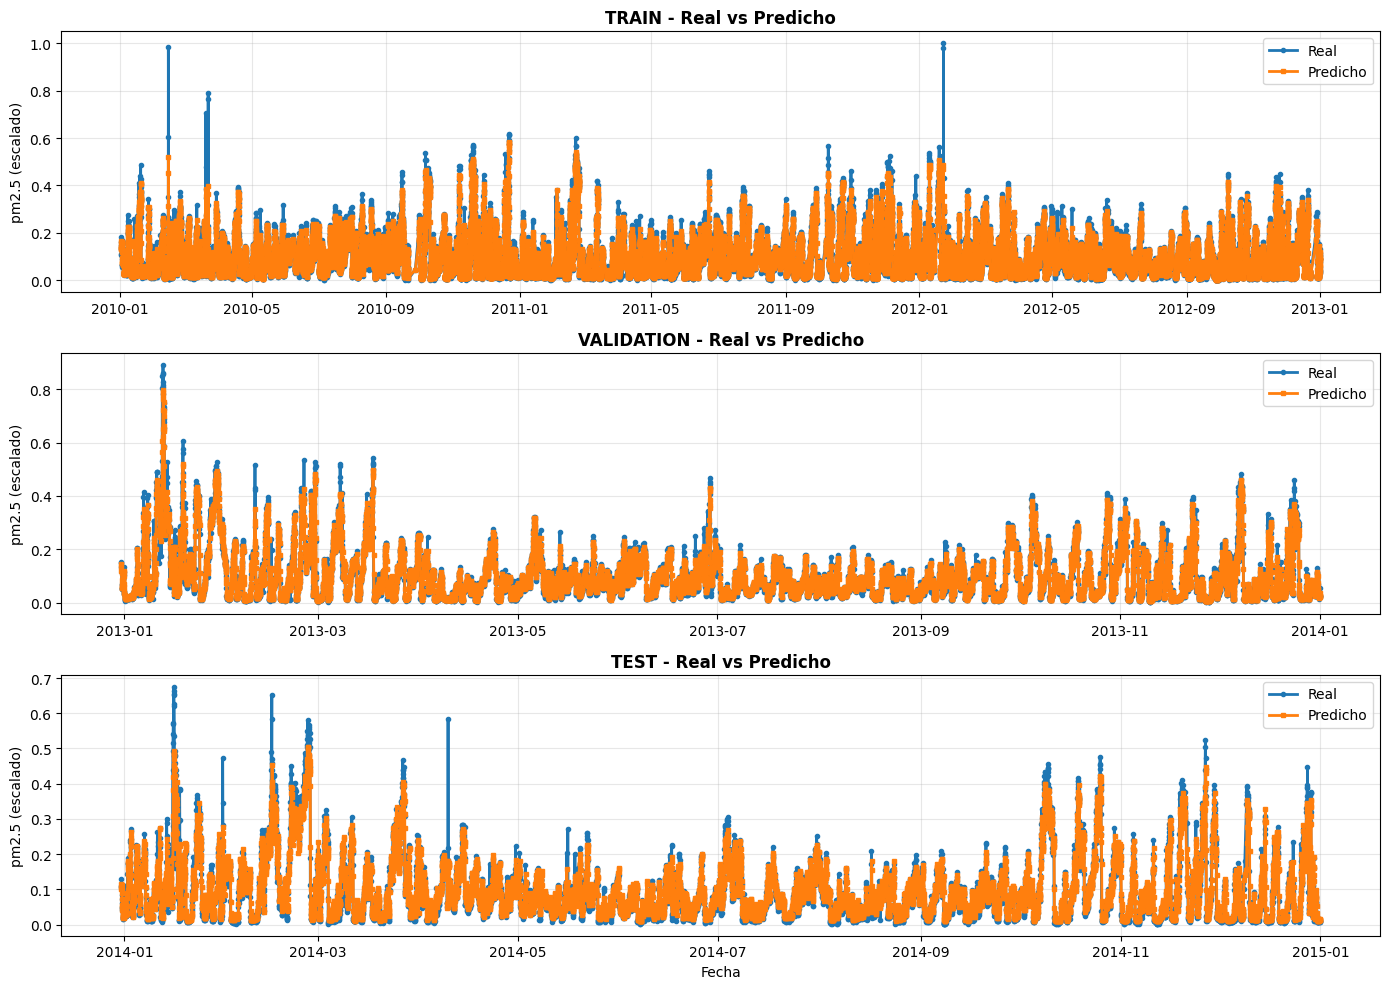


✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 3


[I 2026-05-16 06:16:20,202] A new study created in memory with name: no-name-ff44723c-2be8-466f-a7b5-a59d0bf24de3


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-05-16 06:16:34,647] Trial 0 finished with value: 0.002563785787404133 and parameters: {'n_estimators': 130, 'max_depth': 40, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.002563785787404133.
[I 2026-05-16 06:17:12,033] Trial 1 finished with value: 0.00248466513274026 and parameters: {'n_estimators': 430, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.00248466513274026.
[I 2026-05-16 06:17:35,837] Trial 2 finished with value: 0.0025903361381317902 and parameters: {'n_estimators': 303, 'max_depth': 49, 'min_samples_split': 19, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.00248466513274026.
[I 2026-05-16 06:17:46,421] Trial 3 finished with value: 0.0024710689807960246 and parameters: {'n_estimators': 114, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 3 with value: 

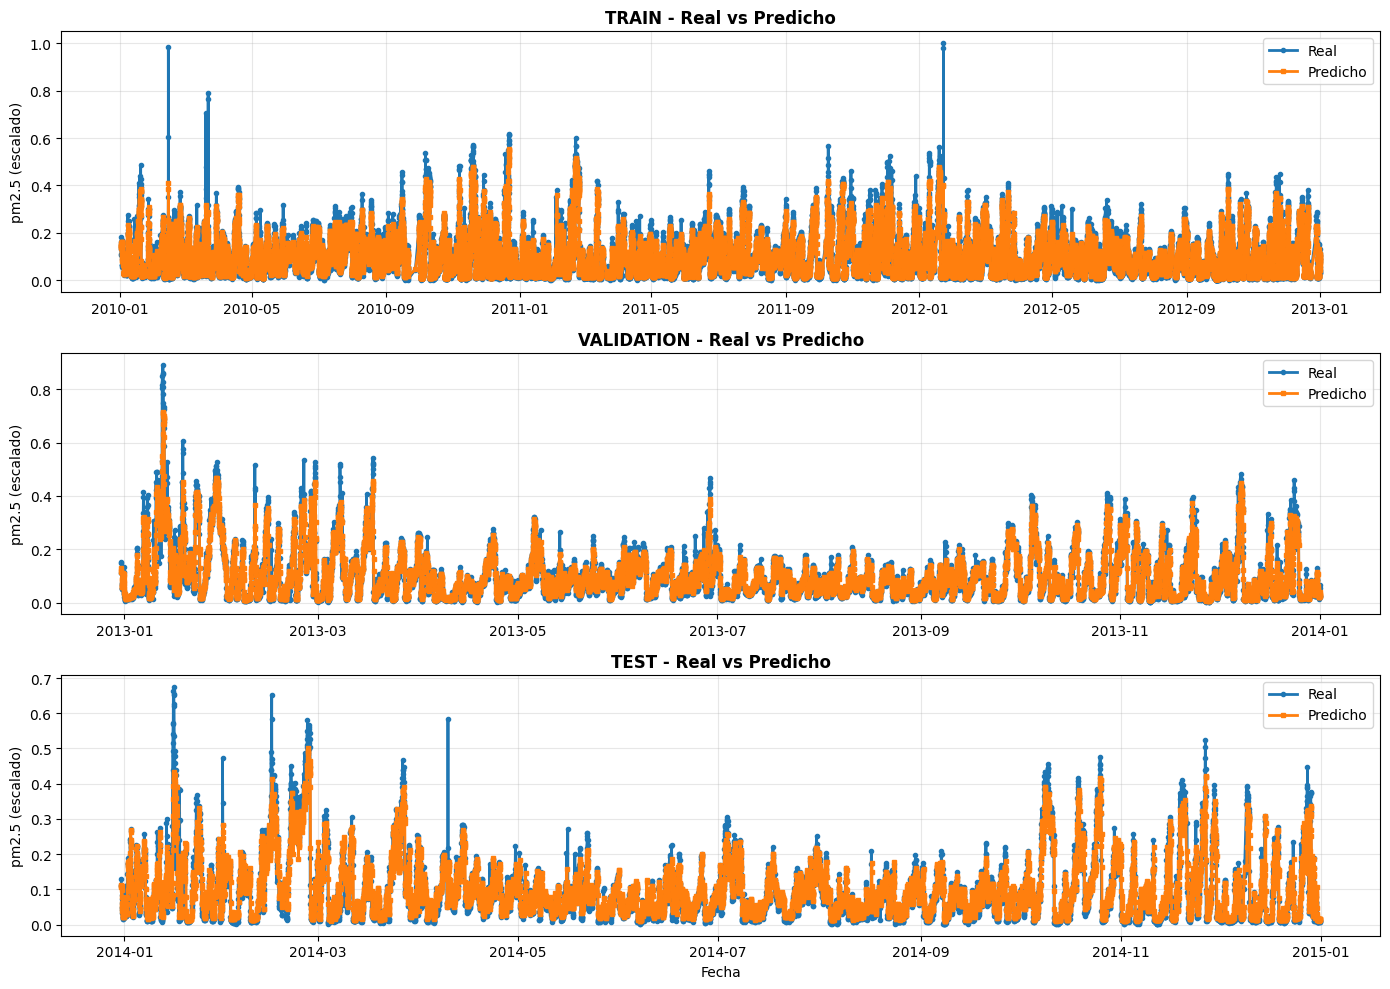


✓ Entrenamiento completado

ENTRENAMIENTO DEL HORIZONTE 4


[I 2026-05-16 07:42:10,540] A new study created in memory with name: no-name-6f8bb193-e4a8-4299-be84-3899af9fb59e


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-05-16 07:42:28,795] Trial 0 finished with value: 0.003248882777123729 and parameters: {'n_estimators': 266, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.003248882777123729.
[I 2026-05-16 07:43:10,766] Trial 1 finished with value: 0.003055737384126217 and parameters: {'n_estimators': 356, 'max_depth': 28, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.003055737384126217.
[I 2026-05-16 07:43:48,518] Trial 2 finished with value: 0.0030345739251200574 and parameters: {'n_estimators': 345, 'max_depth': 46, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.0030345739251200574.
[I 2026-05-16 07:44:38,627] Trial 3 finished with value: 0.003037980023050872 and parameters: {'n_estimators': 437, 'max_depth': 36, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 2 with valu

In [ ]:
import os

for i in range(1,8):

  print("\n" + "="*80)
  print(f"ENTRENAMIENTO DEL HORIZONTE {i}")
  print("="*80)

  #crear carpeta
  path = f'../models/model_rf2_h{i}'
  os.makedirs(path, exist_ok=True)

  #Eliminando filas con target NaN, las X pueden tener faltantes para RF
  X = X_scaled.replace('NaN', np.nan)
  y = y_scaled_dict[f'h{i}'].replace('NaN', np.nan)
  valid_idx = y.notna().squeeze()
  X_clean = X[valid_idx]
  y_clean = y[valid_idx]

  #split data para entrenamiento primer horizonte

  train_end = '2012-12-31'
  val_end = '2013-12-31'

  X_train = X_clean.loc[:train_end]
  X_val = X_clean.loc[train_end:val_end]
  X_test = X_clean.loc[val_end:]

  y_train = y_clean.loc[:train_end]
  y_val = y_clean.loc[train_end:val_end]
  y_test = y_clean.loc[val_end:]

  # ==================== OPTUNA ====================
  study = optuna.create_study(direction='minimize', pruner=MedianPruner())
  study.optimize(objective, n_trials=150, show_progress_bar=True)

  best_params = study.best_params
  print(f"\n✓ Mejores parámetros:\n{best_params}")

  # ==================== ENTRENAR CON MEJORES PARÁMETROS ====================
  X_train_val = pd.concat([X_train, X_val])
  y_train_val = pd.concat([y_train, y_val])

  model_final = RandomForestRegressor(**best_params, random_state=42)
  model_final.fit(X_train_val, y_train_val.values.ravel())

  # ==================== GUARDAR MODELO ====================
  joblib.dump(model_final, f'{path}/model_rf_h{i}.joblib')
  print("✓ Modelo guardado: model_rf_h1.joblib")

  # ==================== CARGAR DESPUÉS ====================
  # model_loaded = joblib.load('{path}/model_rf_h1.joblib')
  # y_pred = model_loaded.predict(X_test)

  # ==================== PREDICCIONES ====================
  y_train_pred = model_final.predict(X_train)
  y_val_pred = model_final.predict(X_val)
  y_test_pred = model_final.predict(X_test)

  # ==================== MÉTRICAS ====================
  metrics_train = calculate_metrics(y_train.values.ravel(), y_train_pred, 'Train')
  metrics_val = calculate_metrics(y_val.values.ravel(), y_val_pred, 'Validation')
  metrics_test = calculate_metrics(y_test.values.ravel(), y_test_pred, 'Test')

  # ==================== GUARDAR COMO CSV ====================
  metrics_df = pd.DataFrame([metrics_train, metrics_val, metrics_test])

  metrics_df.to_csv(f'{path}/metrics_h{i}.csv', index=False)
  print(f"✓ Métricas guardadas: metrics_h{i}.csv")

  # ==================== TABLAS DE MÉTRICAS ====================
  print("\n" + "="*80)
  print("MÉTRICAS - TRAIN")
  print("="*80)
  metrics_train_df = pd.DataFrame([metrics_train])
  print(metrics_train_df.to_string(index=False))

  print("\n" + "="*80)
  print("MÉTRICAS - VALIDATION")
  print("="*80)
  metrics_val_df = pd.DataFrame([metrics_val])
  print(metrics_val_df.to_string(index=False))

  print("\n" + "="*80)
  print("MÉTRICAS - TEST")
  print("="*80)
  metrics_test_df = pd.DataFrame([metrics_test])
  print(metrics_test_df.to_string(index=False))

  # ==================== CSV CON PREDICCIONES ====================
  results_train = pd.DataFrame({
      'real': y_train.values.ravel(),
      'predicho': y_train_pred,
      'set': 'train'
  }, index=y_train.index)

  results_val = pd.DataFrame({
      'real': y_val.values.ravel(),
      'predicho': y_val_pred,
      'set': 'validation'
  }, index=y_val.index)

  results_test = pd.DataFrame({
      'real': y_test.values.ravel(),
      'predicho': y_test_pred,
      'set': 'test'
  }, index=y_test.index)

  results_all = pd.concat([results_train, results_val, results_test])
  results_all.to_csv(f'{path}/predicciones_h{i}.csv')
  print(f"\n✓ CSV guardado: predicciones_h{i}.csv")

  # ==================== GRÁFICA ====================
  fig, axes = plt.subplots(3, 1, figsize=(14, 10))

  # Train
  axes[0].plot(y_train.index, y_train.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[0].plot(y_train.index, y_train_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[0].set_title('TRAIN - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[0].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[0].legend()
  axes[0].grid(True, alpha=0.3)

  # Validation
  axes[1].plot(y_val.index, y_val.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[1].plot(y_val.index, y_val_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[1].set_title('VALIDATION - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[1].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[1].legend()
  axes[1].grid(True, alpha=0.3)

  # Test
  axes[2].plot(y_test.index, y_test.values.ravel(), label='Real', linewidth=2, marker='o', markersize=3)
  axes[2].plot(y_test.index, y_test_pred, label='Predicho', linewidth=2, marker='s', markersize=3)
  axes[2].set_title('TEST - Real vs Predicho', fontsize=12, fontweight='bold')
  axes[2].set_xlabel('Fecha', fontsize=10)
  axes[2].set_ylabel('pm2.5 (escalado)', fontsize=10)
  axes[2].legend()
  axes[2].grid(True, alpha=0.3)

  plt.tight_layout()
  # ==================== GUARDAR FIGURA ====================
  plt.savefig(f'{path}/predicciones_h{i}.png', dpi=300, bbox_inches='tight')
  print(f"✓ Figura guardada: predicciones_h{i}.png")

  plt.show()

  print("\n✓ Entrenamiento completado")